# Fast MLflow Experiment Tracking: Shopping Assistant Prompt Eval

Imagine we run the support chatbot for an online outdoor gear store. It answers customer
questions about orders, returns, sizing and stock. Answering correctly is not enough: the
answers must sound like our support team — detailed but concise, very friendly, and genuinely
helpful, always ending with a clear next step.

We do not know which system prompt gets us there. So we treat it as an experiment loop.

The loop is deliberately small:

1. Start MLflow locally.
2. Run a baseline prompt over three support questions.
3. Run a stronger style-contract prompt over the same questions.
4. Compare reference-based answer similarity and reference-free house-style compliance.

The goal is not to prove the best prompt forever. The goal is to show the evaluation pipeline quickly: prompt version → dataset → scorers → MLflow run → compare → inspect weak examples.


## 1. Setup

Start MLflow in a separate terminal and keep it running:

```bash
mlflow server --host 127.0.0.1 --port 5000 --backend-store-uri sqlite:///mlflow.db
```

Open the UI at <http://127.0.0.1:5000>. This notebook logs two runs into one experiment.


In [1]:
# !pip install "mlflow>=3" openai pandas matplotlib

In [2]:
!pip install "mlflow>=3"

In [3]:
import json
import os

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from mlflow.entities import Feedback
from mlflow.genai.scorers import Guidelines, scorer
from openai import OpenAI

In [4]:
pd.set_option("display.max_colwidth", None)

In [5]:
# Fail fast: this workshop version only supports live LLM calls.
if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY before running this notebook.")

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "shopping_assistant_style_workshop_short"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

# Autolog captures prompts, responses, latency, token usage, and model metadata.
mlflow.openai.autolog()

# Keeps the live workshop snappy by avoiding MLflow's extra first-row validation call.
os.environ["MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION"] = "true"

try:
    mlflow.search_experiments()
except Exception as error:
    raise RuntimeError(
        f"Cannot reach MLflow at {MLFLOW_TRACKING_URI}. Start the server first."
    ) from error

print(f"MLflow ready at {MLFLOW_TRACKING_URI}")
print(f"Experiment '{EXPERIMENT_NAME}' has id {experiment.experiment_id}")


MLflow ready at http://127.0.0.1:5000
Experiment 'shopping_assistant_style_workshop_short' has id 1


## 2. The Assistant Under Test

Every prompt version gets the same store facts. The experiment changes only the writing instructions, so the comparison stays clean.


In [6]:
client = OpenAI()

ASSISTANT_MODEL = "gpt-5.5"
JUDGE_MODEL = "openai:/gpt-5.5"  # MLflow judge format: <provider>:/<model>

STORE_NAME = "Fjord & Field"

STORE_FACTS = """
Store facts you may rely on:
- Orders are packed within 1-2 business days; standard delivery takes another 3-5 business days.
- Standard shipping is free on orders over $75. Express delivery costs $12.
- We ship to Canada in 7-10 business days, and duties are calculated at checkout.
- Returns and exchanges are free within 30 days for unworn items with tags attached.
- Worn items can only be returned if there is a manufacturing defect.
- Backpacks and tents carry a 3-year warranty against manufacturing defects; normal wear is not covered.
- Our hiking boots run about half a size small, so we suggest sizing up half a size for thick socks.
- New newsletter subscribers get 10% off their first order. We do not offer student, influencer or one-off discounts.
- Out-of-stock sizes usually return within about two weeks, and customers can click "Notify me" on the product page.
""".strip()


In [7]:
PROMPT_VERSIONS = {}


def register_prompt_version(version, short_description, style_instructions):
    PROMPT_VERSIONS[version] = {
        "short_description": short_description,
        "style_instructions": style_instructions.strip(),
    }


def build_system_prompt(version):
    config = PROMPT_VERSIONS[version]
    return "\n\n".join([
        f"You are the customer support assistant for {STORE_NAME}, an online outdoor gear store.",
        config["style_instructions"],
        STORE_FACTS,
    ])


def answer(question, prompt_version):
    """Answer one customer question. OpenAI autolog turns the model call into an MLflow trace."""
    with mlflow.tracing.context(tags={
        "prompt_version": prompt_version,
        "trace_kind": "assistant",
    }):
        response = client.responses.create(
            model=ASSISTANT_MODEL,
            input=[
                {"role": "system", "content": build_system_prompt(prompt_version)},
                {"role": "user", "content": question},
            ],
        )

    return response.output_text


## 3. Tiny Eval Dataset

Three examples are enough for a live workshop: one shipping/order question, one return-policy edge case, and one sizing question. The reference answers define the target voice.


In [8]:
examples = [
    {
        "question": "I ordered a jacket on Monday and my order still says processing. Where is it?",
        "reference_answer": (
            "Thanks for checking in, and sorry for the wait! Orders take 1-2 business days to pack and "
            "standard delivery is another 3-5 business days, so a Monday order is right on schedule. "
            "You will get a tracking email the moment it leaves our warehouse - if nothing arrives by "
            "Thursday, reply here with your order number and I will chase it up for you."
        ),
    },
    {
        "question": "Can I return a rain jacket I bought three weeks ago? I have worn it once.",
        "reference_answer": (
            "Happy to help you sort this out. Returns are free within 30 days so you are inside the "
            "window, but we can only take items back unworn with their tags on, which means a jacket you "
            "have worn would not qualify on its own. If something is actually wrong with it, like a failed "
            "seam or zip, send me a photo and I will arrange a free replacement."
        ),
    },
    {
        "question": "Do your hiking boots run true to size?",
        "reference_answer": (
            "Good question - our boots run about half a size small. Most people size up half a size, "
            "especially for hiking in thick wool socks. If you are between sizes, order both and keep the "
            "pair that fits: exchanges and returns are free within 30 days."
        ),
    },
]

eval_dataset = [
    {
        "inputs": {"question": example["question"]},
        "expectations": {"expected_response": example["reference_answer"]},
    }
    for example in examples
]

pd.DataFrame(examples)[["question", "reference_answer"]]


,question,reference_answer
0,I ordered a jacket on Monday and my order still says processing. Where is it?,"Thanks for checking in, and sorry for the wait! Orders take 1-2 business days to pack and standard delivery is another 3-5 business days, so a Monday order is right on schedule. You will get a tracking email the moment it leaves our warehouse - if nothing arrives by Thursday, reply here with your order number and I will chase it up for you."
1,Can I return a rain jacket I bought three weeks ago? I have worn it once.,"Happy to help you sort this out. Returns are free within 30 days so you are inside the window, but we can only take items back unworn with their tags on, which means a jacket you have worn would not qualify on its own. If something is actually wrong with it, like a failed seam or zip, send me a photo and I will arrange a free replacement."
2,Do your hiking boots run true to size?,"Good question - our boots run about half a size small. Most people size up half a size, especially for hiking in thick wool socks. If you are between sizes, order both and keep the pair that fits: exchanges and returns are free within 30 days."


## 4. Scorers

We use two complementary checks:

- **answer_similarity**: reference-based, custom, returns `match`, `partial_match`, or `mismatch`.
- **house_style**: reference-free, checks whether the answer follows the support team's style rules.

For a workshop, this gives a nice contrast without building a full metric suite.


In [9]:
SIMILARITY_LABELS = ("match", "partial_match", "mismatch")

SIMILARITY_PROMPT = """
You compare a shopping assistant's answer with a reference answer written by the support team.

Classify how similar the assistant answer is to the reference answer, considering both the
information it gives and the way it is written.

Choose exactly one label:

match - The answer gives the same customer-facing information, preserves the same important
constraints and next step, and is close enough in voice that the support team would accept it.

partial_match - The answer covers some important information, but misses or changes a fact,
constraint, emphasis, next step, length, or voice in a way the support team would notice.

mismatch - The answer contradicts the reference, invents unsupported information, refuses when it
should answer, gives unsafe or irrelevant advice, or does not answer the customer's question.

Customer question:
{question}

Reference answer:
{reference}

Assistant answer:
{answer}

Return strict JSON with this schema and nothing else:
{{"label": "match|partial_match|mismatch", "rationale": "<one or two sentences>"}}
""".strip()


def parse_similarity(raw_text):
    try:
        parsed = json.loads(raw_text)
        label = str(parsed["label"]).strip().lower().replace("-", "_").replace(" ", "_")
    except (json.JSONDecodeError, KeyError, TypeError, ValueError) as error:
        return "mismatch", f"Could not parse judge response ({error}): {raw_text[:200]}"

    if label not in SIMILARITY_LABELS:
        return "mismatch", f"Judge returned an unknown label: {label}"

    return label, str(parsed.get("rationale", "")).strip()


@scorer
def answer_similarity(inputs, outputs, expectations):
    prompt = SIMILARITY_PROMPT.format(
        question=inputs["question"],
        reference=expectations["expected_response"],
        answer=outputs,
    )

    # Judge calls are not product behavior, so keep them out of OpenAI autolog traces.
    with mlflow.tracing.context(enabled=False):
        response = client.responses.create(
            model=ASSISTANT_MODEL,
            input=[{"role": "user", "content": prompt}],
        )

    label, rationale = parse_similarity(response.output_text)
    return Feedback(value=label, rationale=rationale)


In [10]:
house_style = Guidelines(
    name="house_style",
    guidelines=[
        "The response is between 2 and 4 sentences long.",
        "The response opens by acknowledging the customer's question or situation.",
        "The response is warm and friendly rather than stiff or corporate, and uses no emoji.",
        "The response ends with exactly one concrete next step the customer can take.",
        "The response contains no filler, no repetition and no padding.",
    ],
    model=JUDGE_MODEL,
)

SCORERS = [answer_similarity, house_style]


## 5. Run Harness

One helper records the prompt version, full system prompt, metrics, and per-example evaluations into MLflow.


In [11]:
run_log = []


def similarity_share_metrics(results):
    labels = results.result_df["answer_similarity/value"]
    return {
        f"answer_similarity/{label}_share": float(labels.eq(label).mean())
        for label in SIMILARITY_LABELS
    }


def run_summary(results):
    return {
        **similarity_share_metrics(results),
        "house_style/mean": results.metrics["house_style/mean"],
    }


def run_experiment(prompt_version):
    config = PROMPT_VERSIONS[prompt_version]

    def predict_fn(question):
        return answer(question, prompt_version)

    with mlflow.start_run(run_name=prompt_version) as run:
        mlflow.log_params({
            "prompt_version": prompt_version,
            "description": config["short_description"],
            "assistant_model": ASSISTANT_MODEL,
            "judge_model": JUDGE_MODEL,
            "n_examples": len(eval_dataset),
        })
        mlflow.log_text(build_system_prompt(prompt_version), "system_prompt.txt")

        results = mlflow.genai.evaluate(
            data=eval_dataset,
            predict_fn=predict_fn,
            scorers=SCORERS,
        )
        similarity_metrics = similarity_share_metrics(results)
        mlflow.log_metrics(similarity_metrics)

    run_log.append({
        "prompt_version": prompt_version,
        "description": config["short_description"],
        "run_id": run.info.run_id,
        "results": results,
        **results.metrics,
        **similarity_metrics,
    })

    return results


def score_table(results):
    table = results.result_df.copy()

    table["question"] = table["request"].apply(
        lambda request: next(
            (
                message.get("content")
                for message in request.get("input", [])
                if message.get("role") == "user"
            ),
            None,
        )
    )

    table["answer"] = table["response"].apply(
        lambda response: response
        if isinstance(response, str)
        else next(
            (
                content.get("text")
                for item in response.get("output", [])
                for content in item.get("content", [])
                if content.get("type") == "output_text"
            ),
            None,
        )
    )

    return table.rename(columns={
        "answer_similarity/value": "answer_similarity",
        "house_style/value": "house_style",
    })


SCORE_COLUMNS = ["question", "answer_similarity", "house_style", "answer"]

## 6. Version 1: Minimal Prompt

This is the baseline. It should know the facts, but it has no contract for length, warmth, or next step.


In [12]:
register_prompt_version(
    version="v1_minimal",
    short_description="No style guidance",
    style_instructions="""
Answer the customer's question.
""",
)

results_v1 = run_experiment("v1_minimal")
run_summary(results_v1)

2026/09/24 10:17:37 INFO mlflow.models.evaluation.utils.trace: Auto tracing is temporarily enabled during the model evaluation for computing some metrics and debugging. To disable tracing, call `mlflow.autolog(disable=True)`.


Evaluating:   0%|          | 0/3 [Elapsed: 00:00, Remaining: ?]

{'answer_similarity/match_share': 0.3333333333333333,
 'answer_similarity/partial_match_share': 0.6666666666666666,
 'answer_similarity/mismatch_share': 0.0,
 'house_style/mean': 0.3333333333333333}

In [13]:
score_table(results_v1)[SCORE_COLUMNS]

,question,answer_similarity,house_style,answer
0,I ordered a jacket on Monday and my order still says processing. Where is it?,match,no,"Sorry for the worry! Orders are typically packed within **1–2 business days**, and then standard delivery takes another **3–5 business days** after it ships.\n\nIf your jacket was ordered on **Monday**, “processing” usually means it’s still being picked/packed or is about to ship. You should receive a shipping confirmation with tracking as soon as it leaves our warehouse.\n\nIf it’s been more than **2 business days** with no shipping update, send over your **order number** and I can help look into it."
1,Can I return a rain jacket I bought three weeks ago? I have worn it once.,partial_match,yes,"A rain jacket bought three weeks ago is still within our 30-day return window, but returns/exchanges are only free for items that are unworn with tags attached.\n\nSince it’s been worn once, we can only accept the return if there’s a manufacturing defect. If you believe it’s defective, please send us the order number and a photo/description of the issue, and we’ll help from there."
2,Do your hiking boots run true to size?,partial_match,no,"Our hiking boots run about half a size small, especially if you plan to wear thick hiking socks. We recommend ordering a half size up for the best fit."


## 7. Version 2: Explicit Style Contract

Instead of asking for a vague tone, we describe the target answer shape: length, opening, specific fact, one next step, and no invented policy.


In [14]:
register_prompt_version(
    version="v2_style_contract",
    short_description="Explicit style contract: length, opening, one next step",
    style_instructions="""
Write every reply in the house style:
- 2 to 4 sentences. Detailed enough to be genuinely useful, never padded.
- Open by briefly acknowledging what the customer asked or how they feel.
- Give the specific detail that answers the question, using the store facts below.
- End with exactly one concrete next step the customer can take.
- Sound warm and human, never stiff or corporate. Do not use emoji.
- Never invent a policy, price or date. If the facts below do not cover it, say so and offer to check.
""",
)

results_v2 = run_experiment("v2_style_contract")
run_summary(results_v2)


Evaluating:   0%|          | 0/3 [Elapsed: 00:00, Remaining: ?]

{'answer_similarity/match_share': 0.0,
 'answer_similarity/partial_match_share': 1.0,
 'answer_similarity/mismatch_share': 0.0,
 'house_style/mean': 0.6666666666666666}

In [15]:
score_table(results_v2)[SCORE_COLUMNS]

,question,answer_similarity,house_style,answer
0,I ordered a jacket on Monday and my order still says processing. Where is it?,partial_match,yes,"I get why “processing” feels worrying when you’re waiting on a jacket. Orders are packed within 1–2 business days, then standard delivery takes another 3–5 business days, but I can check your specific order status for you. Please send your order number."
1,Can I return a rain jacket I bought three weeks ago? I have worn it once.,partial_match,yes,"I can help clarify that for you. Because the rain jacket has been worn, it can only be returned if there’s a manufacturing defect; our free 30-day returns apply to unworn items with tags attached. If you think there’s a defect, please send us a photo and your order number so we can check it."
2,Do your hiking boots run true to size?,partial_match,no,"Good question — our hiking boots run about half a size small, especially if you wear thick hiking socks. We suggest sizing up half a size for the best fit. Choose a half size larger than your usual size when ordering."


## 8. Compare Runs

The chart is the live summary. The MLflow UI is still useful for checking the exact prompt artifact and opening per-example traces, but we do not need a separate debugging section for the workshop.


In [16]:
comparison = pd.DataFrame([
    {
        "prompt_version": entry["prompt_version"],
        "description": entry["description"],
        "match": entry.get("answer_similarity/match_share", 0.0),
        "partial_match": entry.get("answer_similarity/partial_match_share", 0.0),
        "mismatch": entry.get("answer_similarity/mismatch_share", 0.0),
        "house_style": entry.get("house_style/mean"),
    }
    for entry in run_log
])

comparison


,prompt_version,description,match,partial_match,mismatch,house_style
0,v1_minimal,No style guidance,0.333333,0.666667,0.0,0.333333
1,v2_style_contract,"Explicit style contract: length, opening, one next step",0.000000,1.000000,0.0,0.666667


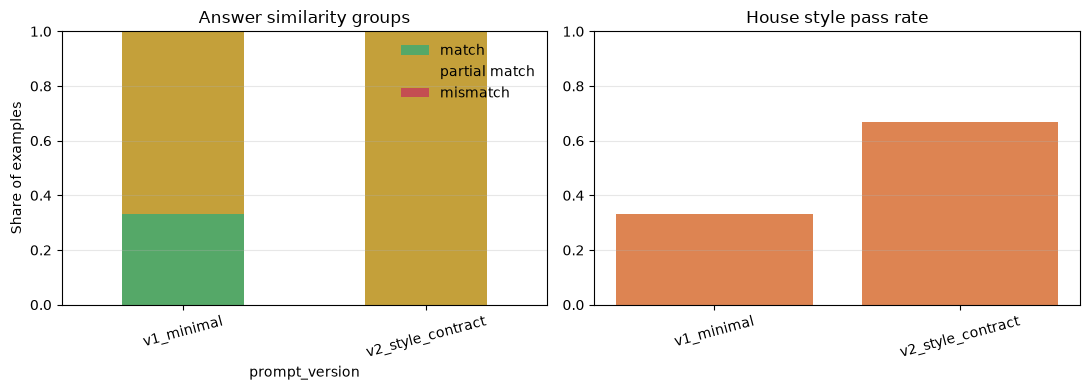

In [17]:
figure, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

similarity_columns = ["match", "partial_match", "mismatch"]

comparison.set_index("prompt_version")[similarity_columns].plot(
    kind="bar",
    stacked=True,
    ax=left,
    color=["#55A868", "#C4A03A", "#C44E52"],
)
left.set_title("Answer similarity groups")
left.set_ylabel("Share of examples")
left.set_ylim(0, 1)
left.legend(["match", "partial match", "mismatch"], frameon=False)

right.bar(comparison["prompt_version"], comparison["house_style"], color="#DD8452")
right.set_title("House style pass rate")
right.set_ylim(0, 1)

for axis in (left, right):
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
interesting = ["tags.mlflow.runName", "params.prompt_version", "params.description"] + [
    column for column in runs.columns if column.startswith("metrics.")
]
runs[[column for column in interesting if column in runs.columns]]


,tags.mlflow.runName,params.prompt_version,params.description,metrics.answer_similarity/match_share,metrics.answer_similarity/mismatch_share,metrics.house_style/mean,metrics.answer_similarity/partial_match_share
0,v2_style_contract,v2_style_contract,"Explicit style contract: length, opening, one next step",0.000000,0.0,0.666667,1.000000
1,v1_minimal,v1_minimal,No style guidance,0.333333,0.0,0.333333,0.666667
2,v2_style_contract,v2_style_contract,"Explicit style contract: length, opening, one next step",0.000000,0.0,0.333333,1.000000
3,v1_minimal,v1_minimal,No style guidance,0.333333,0.0,0.333333,0.666667


## 9. Takeaways

- A tiny eval loop is still a real eval loop: fixed dataset, prompt versions, scorers, runs, and comparison.
- Three examples are enough for teaching mechanics, not enough for product confidence.
- The useful contrast is not “better prompt magic”; it is seeing which failures remain after the prompt gets more specific.
- Reference-based similarity checks whether the answer matches the support team's intended answer. Reference-free style checks whether the answer has the desired shape even before you compare it to a gold answer.
- MLflow is doing the bookkeeping: prompt artifacts, metrics, traces, model metadata, latency, and token usage.
